In [23]:
import numpy as np
import scipy as sp  
import torchaudio, torch, os

https://github.com/audiolabs/rir-generator

In [24]:
!pip install rir-generator

In [25]:
if not os.path.exists('barbaros1.wav'):
    os.system('wget http://dihana.cps.unizar.es/~cadrete/barbaros1.wav')
    

(37001,)


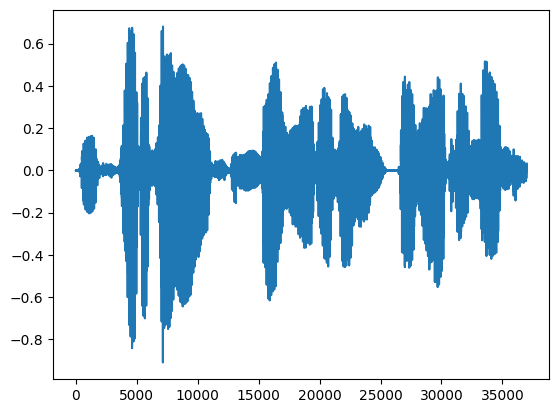

In [26]:
x1, fs = torchaudio.load('barbaros1.wav')
x1 = x1[0].numpy()
print(x1.shape)
from matplotlib import pyplot as plt
plt.plot(x1)
from IPython.display import Audio
Audio(x1,rate=16000)

In [27]:


import rir_generator as rir

h1 = rir.generate(
    c=340,                  # Sound velocity (m/s)
    fs=fs,                  # Sample frequency (samples/s)
    r=[                     # Receiver position(s) [x y z] (m)
        [2, 1.5, 1], 
    ],
    s=[2, 3.5, 2],          # Source position [x y z] (m)
    L=[5, 4, 6],            # Room dimensions [x y z] (m)
    reverberation_time=0.4, # Reverberation time (s)
    nsample=4096,           # Number of output samples
)

print(h1.shape)              # (4096, 3) 


(4096, 1)


(41096,)


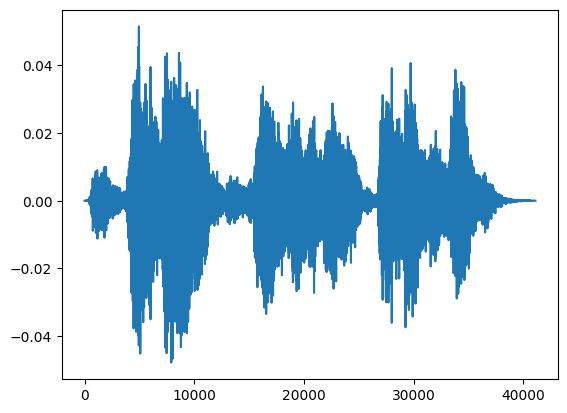

In [28]:
out1 = sp.signal.convolve(h1[:,0], x1)
print(out1.shape)  
plt.plot(out1) 
Audio(out1,rate=16000)

torch.Size([257, 232])
torch.Size([257, 257])


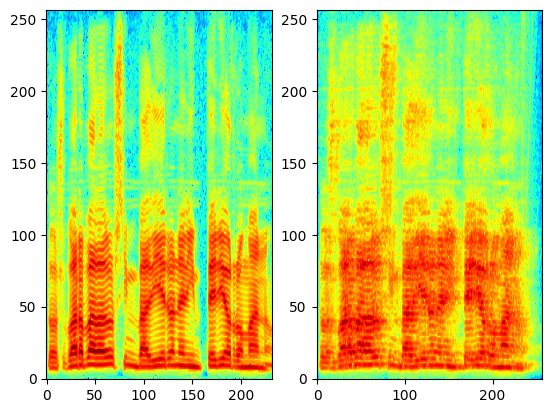

In [29]:
S_x1 = torchaudio.transforms.Spectrogram(
    n_fft=512, win_length=25*16, hop_length=10*16)(torch.tensor(x1))       # 25ms window, 10ms shift
print(S_x1.shape)

plt.subplot(1,2,1)
plt.imshow(S_x1.log().numpy(), cmap='jet', aspect='auto',origin='lower') 

S_out1 = torchaudio.transforms.Spectrogram(
    n_fft=512, win_length=25*16, hop_length=10*16)(torch.tensor(out1))       # 25ms window, 10ms shift
print(S_out1.shape)
plt.subplot(1,2,2)
plt.imshow(S_out1.log().numpy(), cmap='jet', aspect='auto',origin='lower')

(4096, 1)
(41096,)


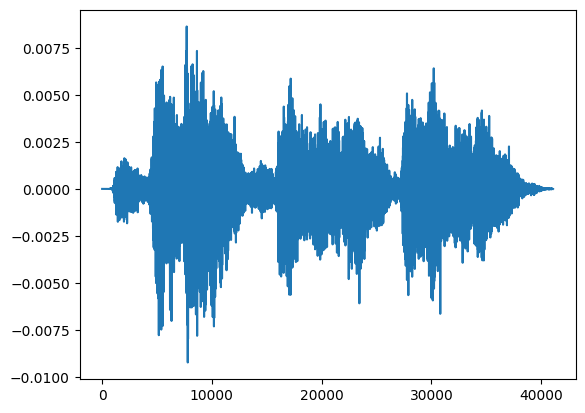

In [30]:
h2 = rir.generate(
    c=340,                  # Sound velocity (m/s)
    fs=fs,                  # Sample frequency (samples/s)
    r=[                     # Receiver position(s) [x y z] (m)
        [2, 17, 1], 
    ],
    s=[2, 3.5, 2],          # Source position [x y z] (m)
    L=[15, 20, 10],            # Room dimensions [x y z] (m)
    reverberation_time=0.7, # Reverberation time (s)
    nsample=4096,           # Number of output samples
)

print(h2.shape)              # (4096, 3) 
out2 = sp.signal.convolve(h2[:,0], x1)
print(out2.shape)  
plt.plot(out2) 
Audio(out2,rate=16000)

torch.Size([257, 257])


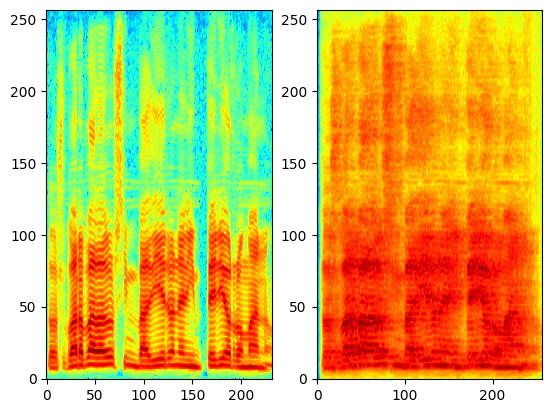

In [31]:
plt.subplot(1,2,1)
plt.imshow(S_x1.log().numpy(), cmap='jet', aspect='auto',origin='lower') 

S_out2 = torchaudio.transforms.Spectrogram(
    n_fft=512, win_length=25*16, hop_length=10*16)(torch.tensor(out2))       # 25ms window, 10ms shift
print(S_out2.shape)
plt.subplot(1,2,2)
plt.imshow(S_out2.log().numpy(), cmap='jet', aspect='auto',origin='lower')

(32000, 1)
(69000,)


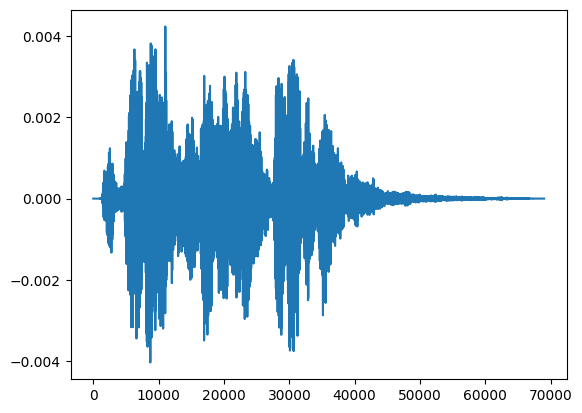

In [32]:
h3 = rir.generate(
    c=340,                  # Sound velocity (m/s)
    fs=fs,                  # Sample frequency (samples/s)
    r=[                     # Receiver position(s) [x y z] (m)
        [20, 17, 1], 
    ],
    s=[2, 3.5, 2],          # Source position [x y z] (m)
    L=[75, 70, 10],            # Room dimensions [x y z] (m)
    reverberation_time=1.2, # Reverberation time (s)
    nsample=32000,           # Number of output samples
)

print(h3.shape)              # (4096, 3) 
out3 = sp.signal.convolve(h3[:,0], x1)
print(out3.shape)  
plt.plot(out3) 
Audio(out3,rate=16000)

torch.Size([257, 432])


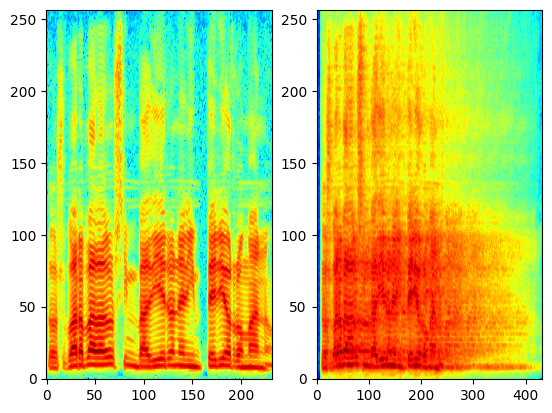

In [33]:
plt.subplot(1,2,1)
plt.imshow(S_x1.log().numpy(), cmap='jet', aspect='auto',origin='lower') 

S_out3 = torchaudio.transforms.Spectrogram(
    n_fft=512, win_length=25*16, hop_length=10*16)(torch.tensor(out3))       # 25ms window, 10ms shift
print(S_out3.shape)
plt.subplot(1,2,2)
plt.imshow(S_out3.log().numpy(), cmap='jet', aspect='auto',origin='lower')